In [2]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI

load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

In [3]:
from pydantic import BaseModel,Field
from langchain_core.tools import tool
import requests
import json

class SearchQuery(BaseModel):
    query:str=Field(description="questions for network queries")

@tool(args_schema=SearchQuery)
def fetch_real_time_data(query):
    """get real time data from website"""
    url="https://api.open-meteo.com/v1/forecast?latitude=52.52&longitude=13.41&t_weather=true"
    print("query in fetch_real_time_data:"+query)
    response=requests.get(url)
    result=json.loads(response.text)
    return result

In [4]:
class WeatherInfo(BaseModel):
    location:str=Field(description="location of the weather")

@tool(args_schema=WeatherInfo)
def get_weather(location):
    """get weather based on the location"""
    if location.lower() in ['beijing']:
        return "北京的温度是17度，天气良好"
    elif location.lower() == 'shanghai':
        return "上海的温度是30度，天气多云"
    else:
        return "未查询到天气信息"

In [5]:
from sqlalchemy import create_engine, Table, Column, Integer, String, MetaData
from sqlalchemy.orm import declarative_base, sessionmaker
import pymysql  # ✅ 显式导入，让 SQLAlchemy 识别

# 创建基类
Base = declarative_base()

class User(Base):
    __tablename__ = 'users'
    id = Column(Integer, primary_key=True)
    name = Column(String(50))
    age = Column(Integer)
    email = Column(String(100))
    phone = Column(String(15))

# ✅ mysql:// → mysql+pymysql://，用 PyMySQL 驱动
DATABASE_URI = os.getenv("DATABASE_URI")
engine = create_engine(DATABASE_URI, echo=True)

Base.metadata.create_all(engine)

Session = sessionmaker(bind=engine)
session = Session()

2026-06-18 17:03:51,474 INFO sqlalchemy.engine.Engine SELECT DATABASE()
2026-06-18 17:03:51,503 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-18 17:03:51,569 INFO sqlalchemy.engine.Engine SELECT @@sql_mode
2026-06-18 17:03:51,570 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-18 17:03:51,581 INFO sqlalchemy.engine.Engine SELECT @@lower_case_table_names
2026-06-18 17:03:51,583 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-18 17:03:51,605 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-06-18 17:03:51,635 INFO sqlalchemy.engine.Engine DESCRIBE `langgraph`.`users`
2026-06-18 17:03:51,637 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-06-18 17:03:51,680 INFO sqlalchemy.engine.Engine COMMIT


In [6]:
from typing import Optional
class UserInfo(BaseModel):
    name: str=Field(description="The name of the user")
    age: Optional[int]=Field(description="The age of the user")
    email:str=Field(description="The email address of the user")
    phone:Optional[str]=Field(description="The phone number of the user")

@tool(args_schema=UserInfo)
def insert_db(name,age,email,phone):
    """insert the user info into database"""
    session=Session()
    try:
        user=UserInfo(name=name,age=age,email=email,phone=phone)
        session.add(user)
        session.commit()
        return {"messages":[f"数据已成功存储到数据库中"]}
    except Exception as e:
        session.rollback()
        return {"messages":[f"数据存储失败，异常是{e}"]}
    finally:
        session.close()


In [7]:
from langgraph.prebuilt import ToolNode

tools=[fetch_real_time_data,get_weather,insert_db]
tool_node=ToolNode(tools)
llm_with_tools=llm.bind_tools(tools)

In [8]:
from typing import Union


class ConversationResponse(BaseModel):
    """A conversation response to the user's query"""
    response:str=Field(description="A conversation response to the user's query")

class FinalResponse(BaseModel):
    """Final response containing either user info or a conversational response"""
    final_output:Union[ConversationResponse,SearchQuery,WeatherInfo,UserInfo]

In [9]:
from langchain_core.messages import AIMessage,HumanMessage
def chat_with_model(state):
    """generate structured response"""
    print("Current conversation state:",state)
    print("-------------------")
    messages=state["messages"]
    responseFromAI=llm.with_structured_output(FinalResponse,method="function_calling").invoke(messages)
    return {
        "messages":[AIMessage(content=str(responseFromAI))],
        "structured_output":responseFromAI.final_output}

In [10]:
def final_response(state):
    """conversation final answer for user"""
    print("final answer current state",state)
    print("------------------")
    messages=state["messages"]
    response=llm.invoke(messages)
    return {"messages":[response]}

In [11]:
def execute_function(state):
    """generate natural language response"""
    print("execute function, current state",state)
    print("---------------------------")
    output=state["structured_output"]
    
    responseFromLLM=llm_with_tools.invoke(str(output))
    # print("responseFromLLM:"+responseFromLLM)
    response=tool_node.invoke({"messages":[responseFromLLM]})
    print(f"response:{response}")
    response=response["messages"][0].content
    return {"messages":[response]}



In [12]:
from typing import Any,List,TypedDict,Optional
from typing_extensions import Annotated
from langchain_core.messages import AnyMessage
import operator

class AgentState(TypedDict):
    messages:Annotated[List[AnyMessage],operator.add]
    structured_output:Optional[Any]

In [13]:
def generate_branch(state:AgentState):
    """route of the agent"""
    output=state["structured_output"]
    if isinstance(output, ConversationResponse):
        return False
    else:
        return True

In [14]:
from langgraph.graph import StateGraph,START,END

graph=StateGraph(AgentState)

graph.add_node("chat_with_model",chat_with_model)
graph.add_node("final_response",final_response)
graph.add_node("execute_function",execute_function)

graph.add_edge(START,"chat_with_model")
graph.add_conditional_edges("chat_with_model",generate_branch,{
    True:"execute_function",
    False: "final_response"
})
graph.set_finish_point("final_response")
graph.set_finish_point("execute_function")

graph=graph.compile()

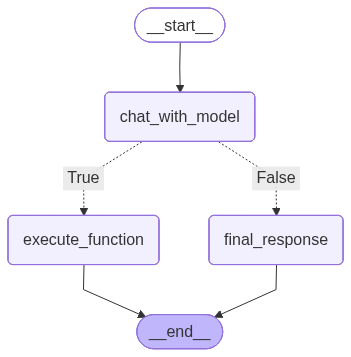

In [15]:
from IPython.display import display,Image
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [16]:
from langchain_core.messages import AIMessage

query="你好，简单介绍一下你自己"
input_message={"messages":[HumanMessage(content=query)]}

result=graph.invoke(input_message)

result

Current conversation state: {'messages': [HumanMessage(content='你好，简单介绍一下你自己', additional_kwargs={}, response_metadata={})]}
-------------------
final answer current state {'messages': [HumanMessage(content='你好，简单介绍一下你自己', additional_kwargs={}, response_metadata={}), AIMessage(content="final_output=ConversationResponse(response='你好！我是你的智能助手，由先进的AI技术驱动。我可以帮助你完成各种任务，比如：\\n\\n1. **回答问题** - 无论是知识性的问题还是日常疑问\\n2. **信息查询** - 搜索网络信息、查询天气等\\n3. **记录信息** - 帮你保存和管理个人信息\\n4. **日常交流** - 陪你聊天、提供建议\\n\\n我目前可以调用一些工具来更好地为你服务，比如搜索网络、查询天气、记录用户信息等。虽然我还在不断学习和进化，但我会尽我所能为你提供准确、有用的帮助！\\n\\n有什么我可以帮你的吗？😊')", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])], 'structured_output': ConversationResponse(response='你好！我是你的智能助手，由先进的AI技术驱动。我可以帮助你完成各种任务，比如：\n\n1. **回答问题** - 无论是知识性的问题还是日常疑问\n2. **信息查询** - 搜索网络信息、查询天气等\n3. **记录信息** - 帮你保存和管理个人信息\n4. **日常交流** - 陪你聊天、提供建议\n\n我目前可以调用一些工具来更好地为你服务，比如搜索网络、查询天气、记录用户信息等。虽然我还在不断学习和进化，但我会尽我所能为你提供准确、有用的帮助！\n\n有什么我可以帮你的吗？😊')}
------------------


{'messages': [HumanMessage(content='你好，简单介绍一下你自己', additional_kwargs={}, response_metadata={}),
  AIMessage(content="final_output=ConversationResponse(response='你好！我是你的智能助手，由先进的AI技术驱动。我可以帮助你完成各种任务，比如：\\n\\n1. **回答问题** - 无论是知识性的问题还是日常疑问\\n2. **信息查询** - 搜索网络信息、查询天气等\\n3. **记录信息** - 帮你保存和管理个人信息\\n4. **日常交流** - 陪你聊天、提供建议\\n\\n我目前可以调用一些工具来更好地为你服务，比如搜索网络、查询天气、记录用户信息等。虽然我还在不断学习和进化，但我会尽我所能为你提供准确、有用的帮助！\\n\\n有什么我可以帮你的吗？😊')", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[]),
  AIMessage(content='你好！我是DeepSeek，由深度求索公司创造的AI助手。😊\n\n简单介绍一下自己：\n\n**基本信息**\n- 纯文本模型，支持阅读链接和上传文件（图像、txt、pdf、ppt、word、excel等）\n- 上下文长度1M，可以一次性处理像《三体》三部曲那么大体量的内容\n- 知识截止日期：2025年5月\n\n**特色功能**\n- ✅ 支持联网搜索（需要手动开启）\n- ✅ 支持语音输入（App端）\n- ✅ 完全免费使用\n- ❌ 不支持多模态识别（但能读取上传文件中的文字）\n\n**我的风格**\n热情、细腻、乐于助人，会用你使用的语言回复你。无论是回答问题、处理文档、还是日常聊天，我都会尽力提供帮助！\n\n有什么我可以帮你的吗？尽管问～✨', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 180, 'prompt_tokens': 157, 'total_tokens': 337

In [17]:
query="小米汽车"
input_message={"messages":[HumanMessage(content=query)]}

result=graph.invoke(input_message)

result["messages"][-1]

Current conversation state: {'messages': [HumanMessage(content='小米汽车', additional_kwargs={}, response_metadata={})]}
-------------------
execute function, current state {'messages': [HumanMessage(content='小米汽车', additional_kwargs={}, response_metadata={}), AIMessage(content="final_output=SearchQuery(query='小米汽车')", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])], 'structured_output': SearchQuery(query='小米汽车')}
---------------------------
query in fetch_real_time_data:小米汽车
response:{'messages': [ToolMessage(content='{"latitude": 52.52, "longitude": 13.419998, "generationtime_ms": 0.00095367431640625, "utc_offset_seconds": 0, "timezone": "GMT", "timezone_abbreviation": "GMT", "elevation": 38.0}', name='fetch_real_time_data', tool_call_id='call_00_cF0v5LjoQuFlTG5qsWKG2062')]}


'{"latitude": 52.52, "longitude": 13.419998, "generationtime_ms": 0.00095367431640625, "utc_offset_seconds": 0, "timezone": "GMT", "timezone_abbreviation": "GMT", "elevation": 38.0}'